In [1]:
import pandas as pd

# Lệnh nạp dữ liệu từ file csv vào biến 'df' (Dataframe)
df = pd.read_csv('Crop_recommendation.csv')

# Hiển thị 5 dòng đầu tiên để xác nhận nạp thành công
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
print(df.shape)

(2200, 8)


In [29]:
# Kiểm tra chi tiết giá trị thiếu và kiểu dữ liệu
print('--- Thông tin kiểu dữ liệu ---')
display(df.info())

print('\n--- Số lượng giá trị thiếu mỗi cột ---')
display(df.isnull().sum())

--- Thông tin kiểu dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


None


--- Số lượng giá trị thiếu mỗi cột ---


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


### Nhận xét từ bảng thống kê (describe):

1. **Sự đa dạng của cây trồng:** Các chỉ số dinh dưỡng (N, P, K) có độ lệch chuẩn (std) rất lớn, cho thấy dữ liệu bao phủ nhiều loại cây trồng có nhu cầu dinh dưỡng rất khác nhau.
2. **Chỉ số Kali (K) đặc biệt:** Giá trị tối đa (Max) của K lên tới 205 (trung bình chỉ 48), chứng tỏ có những loại cây cụ thể cần lượng Kali cực cao.
3. **Môi trường đất lý tưởng:**
   - **pH:** Trung bình 6.47 là môi trường đất hơi acid nhẹ đến trung tính, rất tốt cho đa số cây trồng.
   - **Nhiệt độ:** Trung bình 25.6°C phù hợp với khí hậu nhiệt đới/cận nhiệt đới.
4. **Lượng mưa (Rainfall):** Dải giá trị rộng từ 20mm đến gần 300mm, giúp phân loại rõ rệt giữa cây chịu hạn và cây cần nhiều nước.

In [27]:
# Kiểm tra số lượng dòng trùng lặp trong tập dữ liệu
duplicate_count = df.duplicated().sum()
print(f'Số lượng dòng trùng lặp: {duplicate_count}')

if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print('Không có dòng dữ liệu nào bị trùng lặp. Tập dữ liệu rất sạch!')

Số lượng dòng trùng lặp: 0
Không có dòng dữ liệu nào bị trùng lặp. Tập dữ liệu rất sạch!


### Kết luận EDA Sơ bộ:
- **Dữ liệu sạch:** 100% không có giá trị thiếu, không có dòng trùng lặp.
- **Đặc trưng mạnh:** Các yếu tố N, P, K và Lượng mưa là những chỉ số có tính phân loại cây trồng rõ rệt nhất.
- **Sẵn sàng:** Tập dữ liệu đã đủ tiêu chuẩn để thực hiện chia tập Train/Test và huấn luyện các mô hình phân loại.

In [7]:
# unique: 22: Có tổng cộng 22 loại cây trồng khác nhau trong tập dữ liệu.
# freq: 100: Mỗi loại cây trồng có đúng 100 mẫu dữ liệu. Tập dữ liệu rất cân bằng (balanced dataset),
# cực kỳ lý tưởng để huấn luyện mô hình phân loại mà không lo bị lệch về một nhóm nào.
df.describe(include='object')

,label
count,2200
unique,22
top,rice
freq,100


/tmp/ipykernel_2927/2727024852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='N', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_2927/2727024852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='P', data=df, ax=axes[1], palette='magma')
/tmp/ipykernel_2927/2727024852.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='K', data=df, ax=axes[2], palette='plasma')


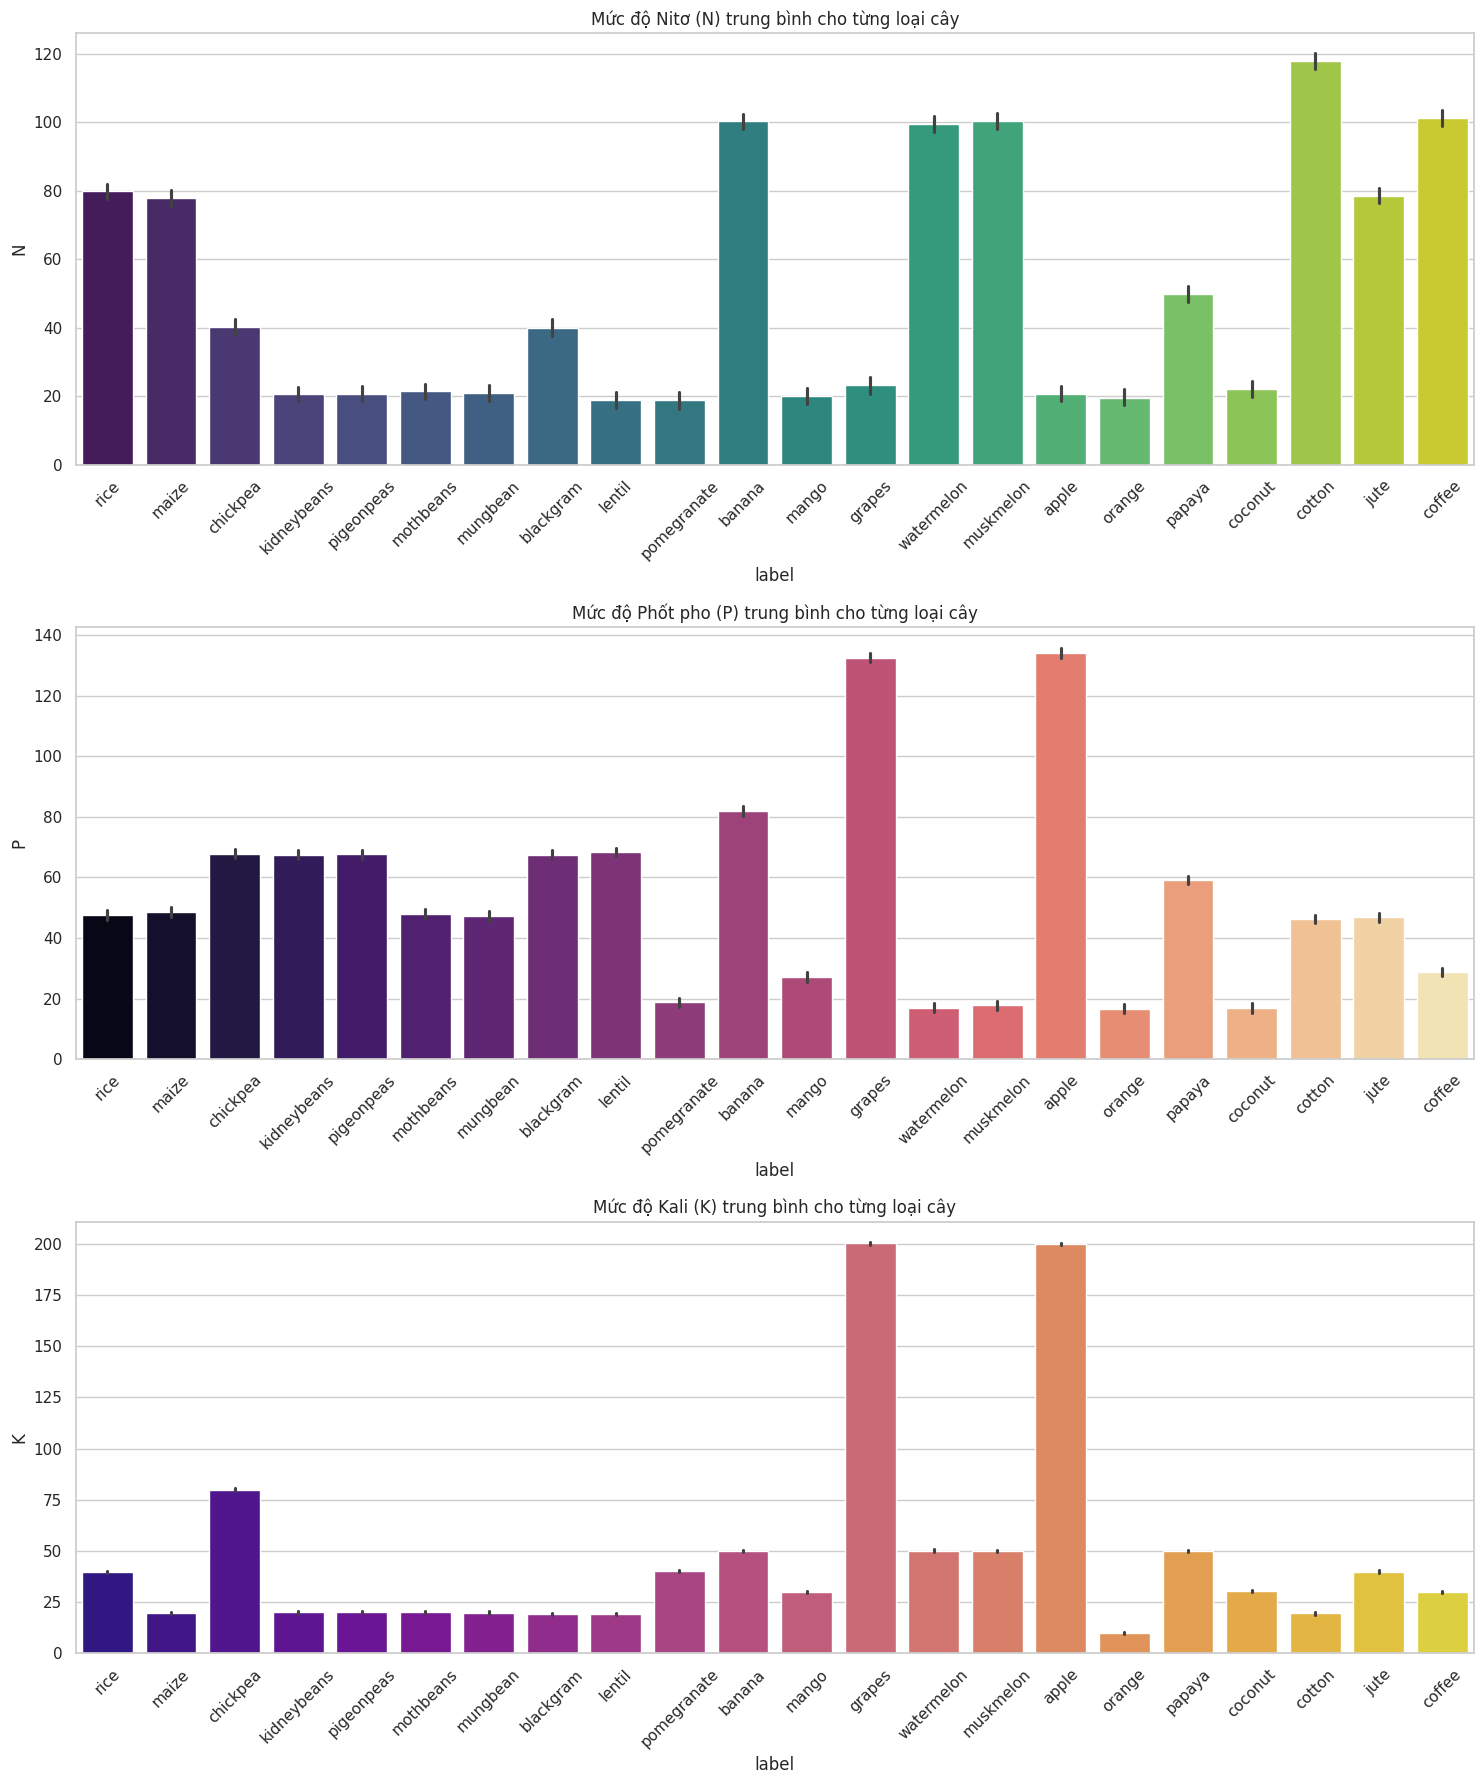

In [10]:
# 1. Trực quan hóa các chỉ số dinh dưỡng (N, P, K)
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

sns.barplot(x='label', y='N', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Mức độ Nitơ (N) trung bình cho từng loại cây')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='label', y='P', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Mức độ Phốt pho (P) trung bình cho từng loại cây')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x='label', y='K', data=df, ax=axes[2], palette='plasma')
axes[2].set_title('Mức độ Kali (K) trung bình cho từng loại cây')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")

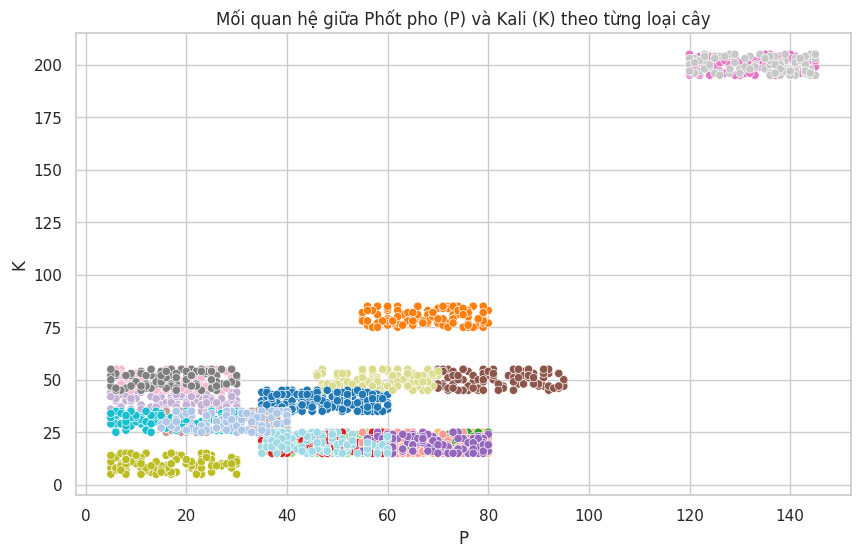

In [13]:
# Vẽ biểu đồ phân tán giữa P và K vì chúng thường có tương quan mạnh ở một số loài cây
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='P', y='K', hue='label', palette='tab20', legend=False)
plt.title('Mối quan hệ giữa Phốt pho (P) và Kali (K) theo từng loại cây')
plt.grid(True)
plt.show()

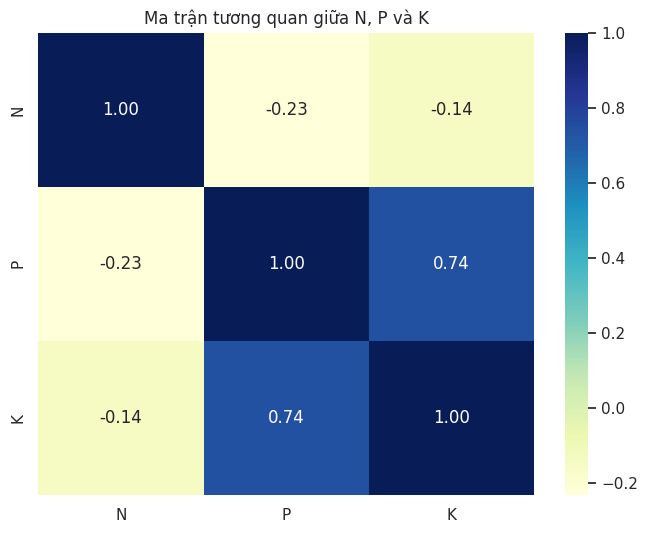

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán ma trận tương quan cho N, P, K
subset_df = df[['N', 'P', 'K']]
corr_matrix = subset_df.corr()

# Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Ma trận tương quan giữa N, P và K')
plt.show()

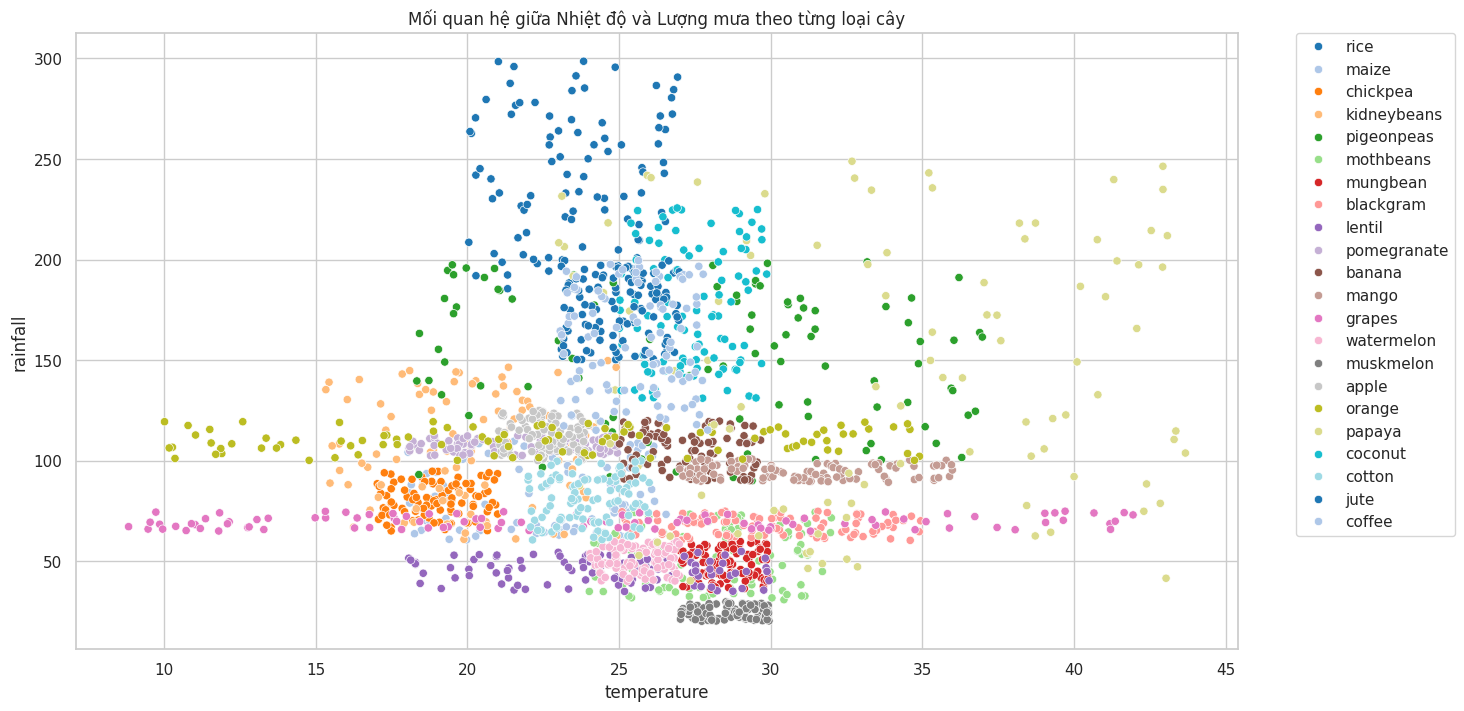

In [11]:
# 2. Trực quan hóa các yếu tố môi trường (Nhiệt độ, Lượng mưa)
plt.figure(figsize=(15, 8))
sns.scatterplot(x='temperature', y='rainfall', hue='label', data=df, palette='tab20')
plt.title('Mối quan hệ giữa Nhiệt độ và Lượng mưa theo từng loại cây')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

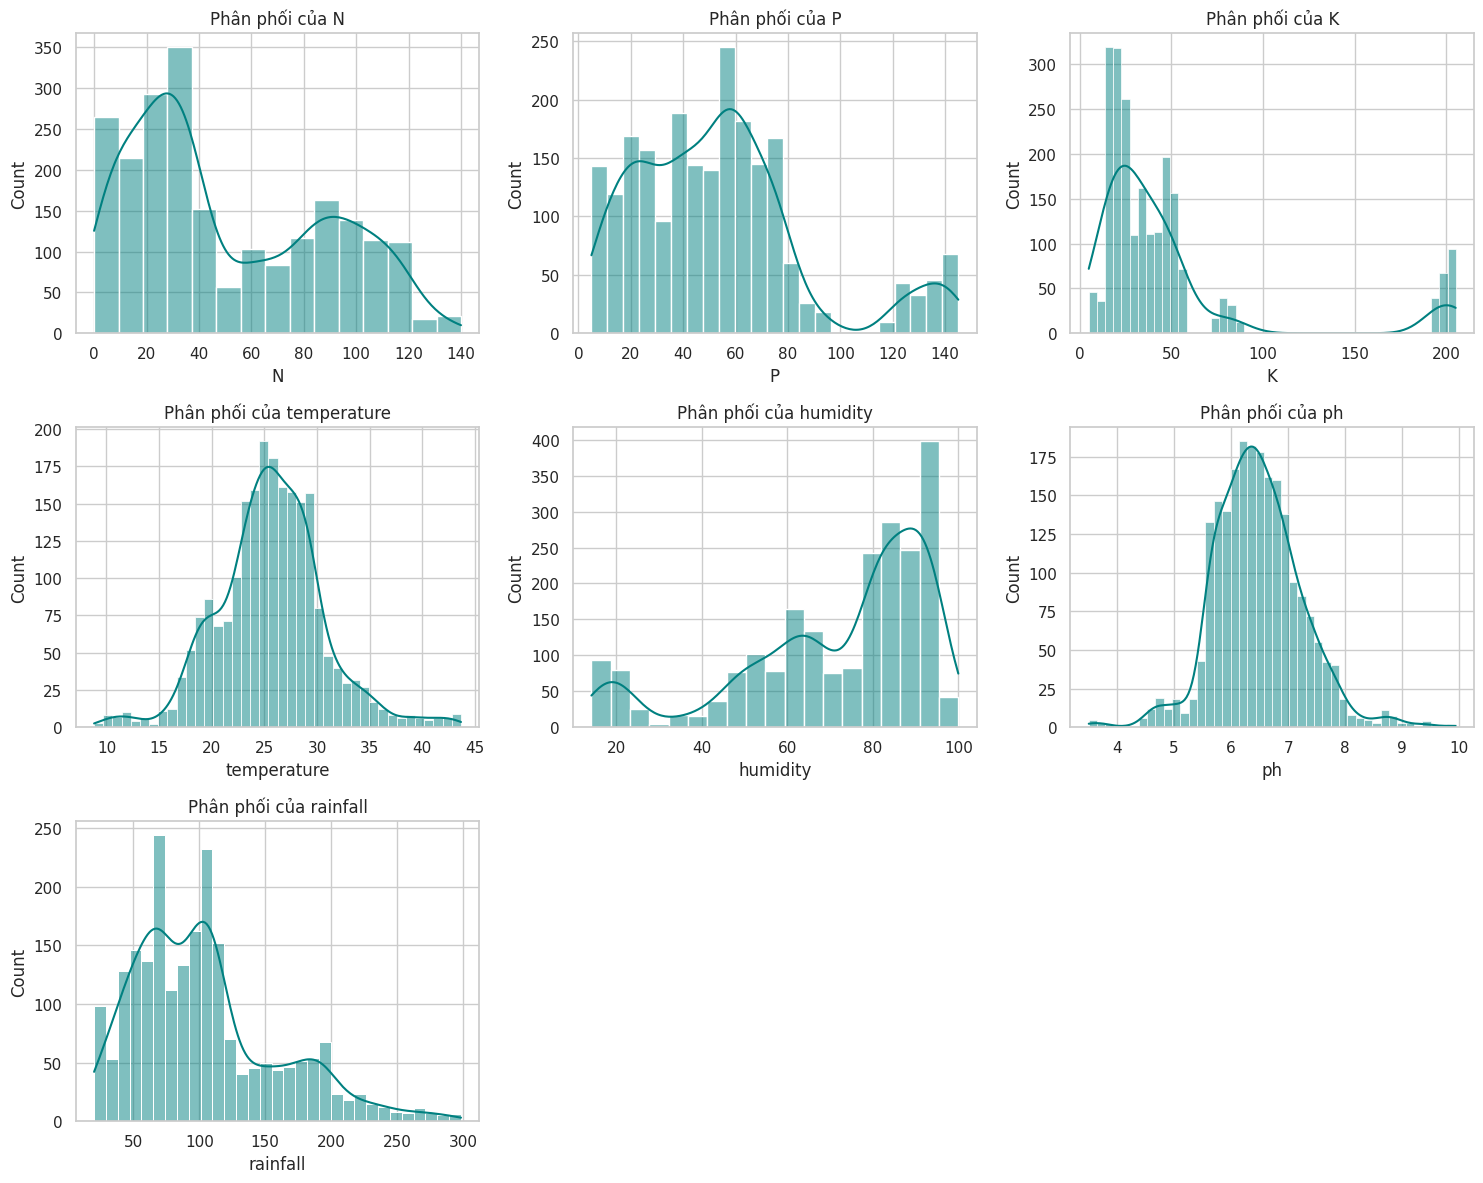

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

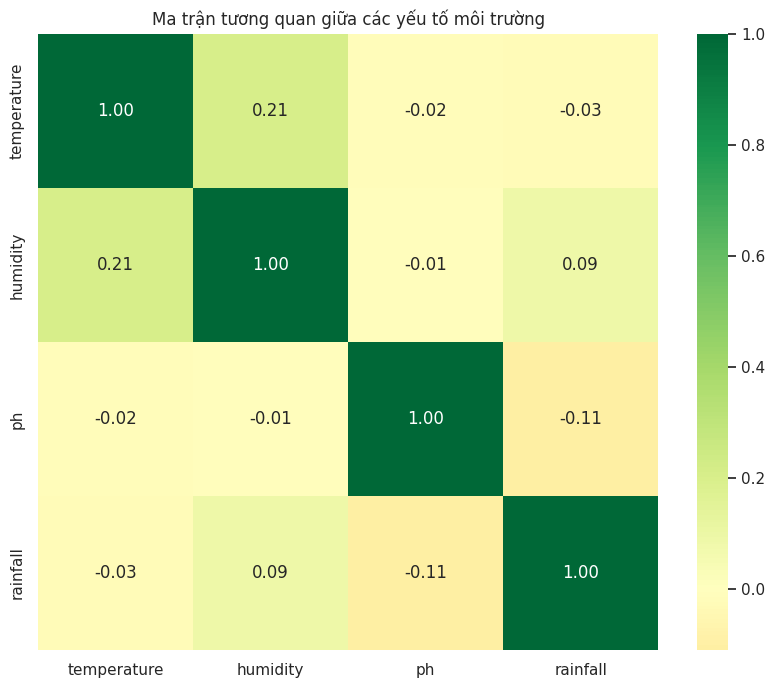

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán ma trận tương quan cho các yếu tố môi trường
env_features = df[['temperature', 'humidity', 'ph', 'rainfall']]
env_corr = env_features.corr()

# Vẽ biểu đồ nhiệt
plt.figure(figsize=(10, 8))
sns.heatmap(env_corr, annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title('Ma trận tương quan giữa các yếu tố môi trường')
plt.show()

# BÁO CÁO PHÂN TÍCH DỮ LIỆU GỢI Ý CÂY TRỒNG (EDA REPORT)

## 1. Tổng quan tập dữ liệu
- **Kích thước:** 2200 mẫu dữ liệu với 8 cột thuộc tính (7 đặc trưng kỹ thuật và 1 nhãn mục tiêu).
- **Chất lượng:** Dữ liệu hoàn thiện 100%, không có giá trị thiếu (Missing values).
- **Độ cân bằng:** Tập dữ liệu cực kỳ cân bằng với 22 loại cây trồng, mỗi loại có đúng 100 mẫu, rất lý tưởng để huấn luyện mô hình.

## 2. Phân tích đặc trưng dinh dưỡng (N, P, K)
- **Nitơ (N):** Có sự phân bổ rộng, các cây như Cà phê, Bông có nhu cầu Đạm rất cao.
- **Phốt pho (P) & Kali (K):**
    - Có mối tương quan thuận rất mạnh (**0.74**).
    - Nhóm cây ăn quả như **Táo (Apple)** và **Nho (Grapes)** có nhu cầu P và K đột biến (P > 120, K > 190), tách biệt hoàn toàn so với các nhóm cây khác.

## 3. Phân tích yếu tố môi trường
- **Lượng mưa (Rainfall):** Là yếu tố phân loại quan trọng nhất cho nhóm cây ưa nước như **Lúa (Rice)** (>200mm) và nhóm chịu hạn như **Dưa vàng (Muskmelon)** (<30mm).
- **Độ pH:** Đa số tập trung ở mức 6.0 - 7.0, là môi trường đất lý tưởng cho nông nghiệp.
- **Tương quan môi trường:**
    - **Tương quan yếu:** Khác với N-P-K, các yếu tố môi trường (nhiệt độ, độ ẩm, pH, lượng mưa) có mức độ tương quan với nhau rất thấp (hầu hết các hệ số đều gần bằng 0).
    - **Độ ẩm và Nhiệt độ (0.21):** Có một mối liên hệ thuận nhẹ giữa nhiệt độ và độ ẩm, nhưng không quá đáng kể.
    - **Tính độc lập cao:** Điều này cho thấy các yếu tố môi trường này cung cấp những thông tin độc lập và riêng biệt cho mô hình, giúp việc phân loại cây trồng trở nên đa chiều và chính xác hơn.

## 4. Kết luận
Các đặc trưng trong tập dữ liệu có tính phân tách (separability) rất cao giữa các nhãn cây trồng. Điều này dự báo các mô hình học máy (như Random Forest hoặc SVM) sẽ đạt được độ chính xác rất cao trên tập dữ liệu này.

### Kết luận EDA Sơ bộ:
- **Dữ liệu sạch:** 100% không có giá trị thiếu, không có dòng trùng lặp.
- **Đặc trưng mạnh:** Các yếu tố N, P, K và Lượng mưa là những chỉ số có tính phân loại cây trồng rõ rệt nhất.
- **Sẵn sàng:** Tập dữ liệu đã đủ tiêu chuẩn để thực hiện chia tập Train/Test và huấn luyện các mô hình phân loại.

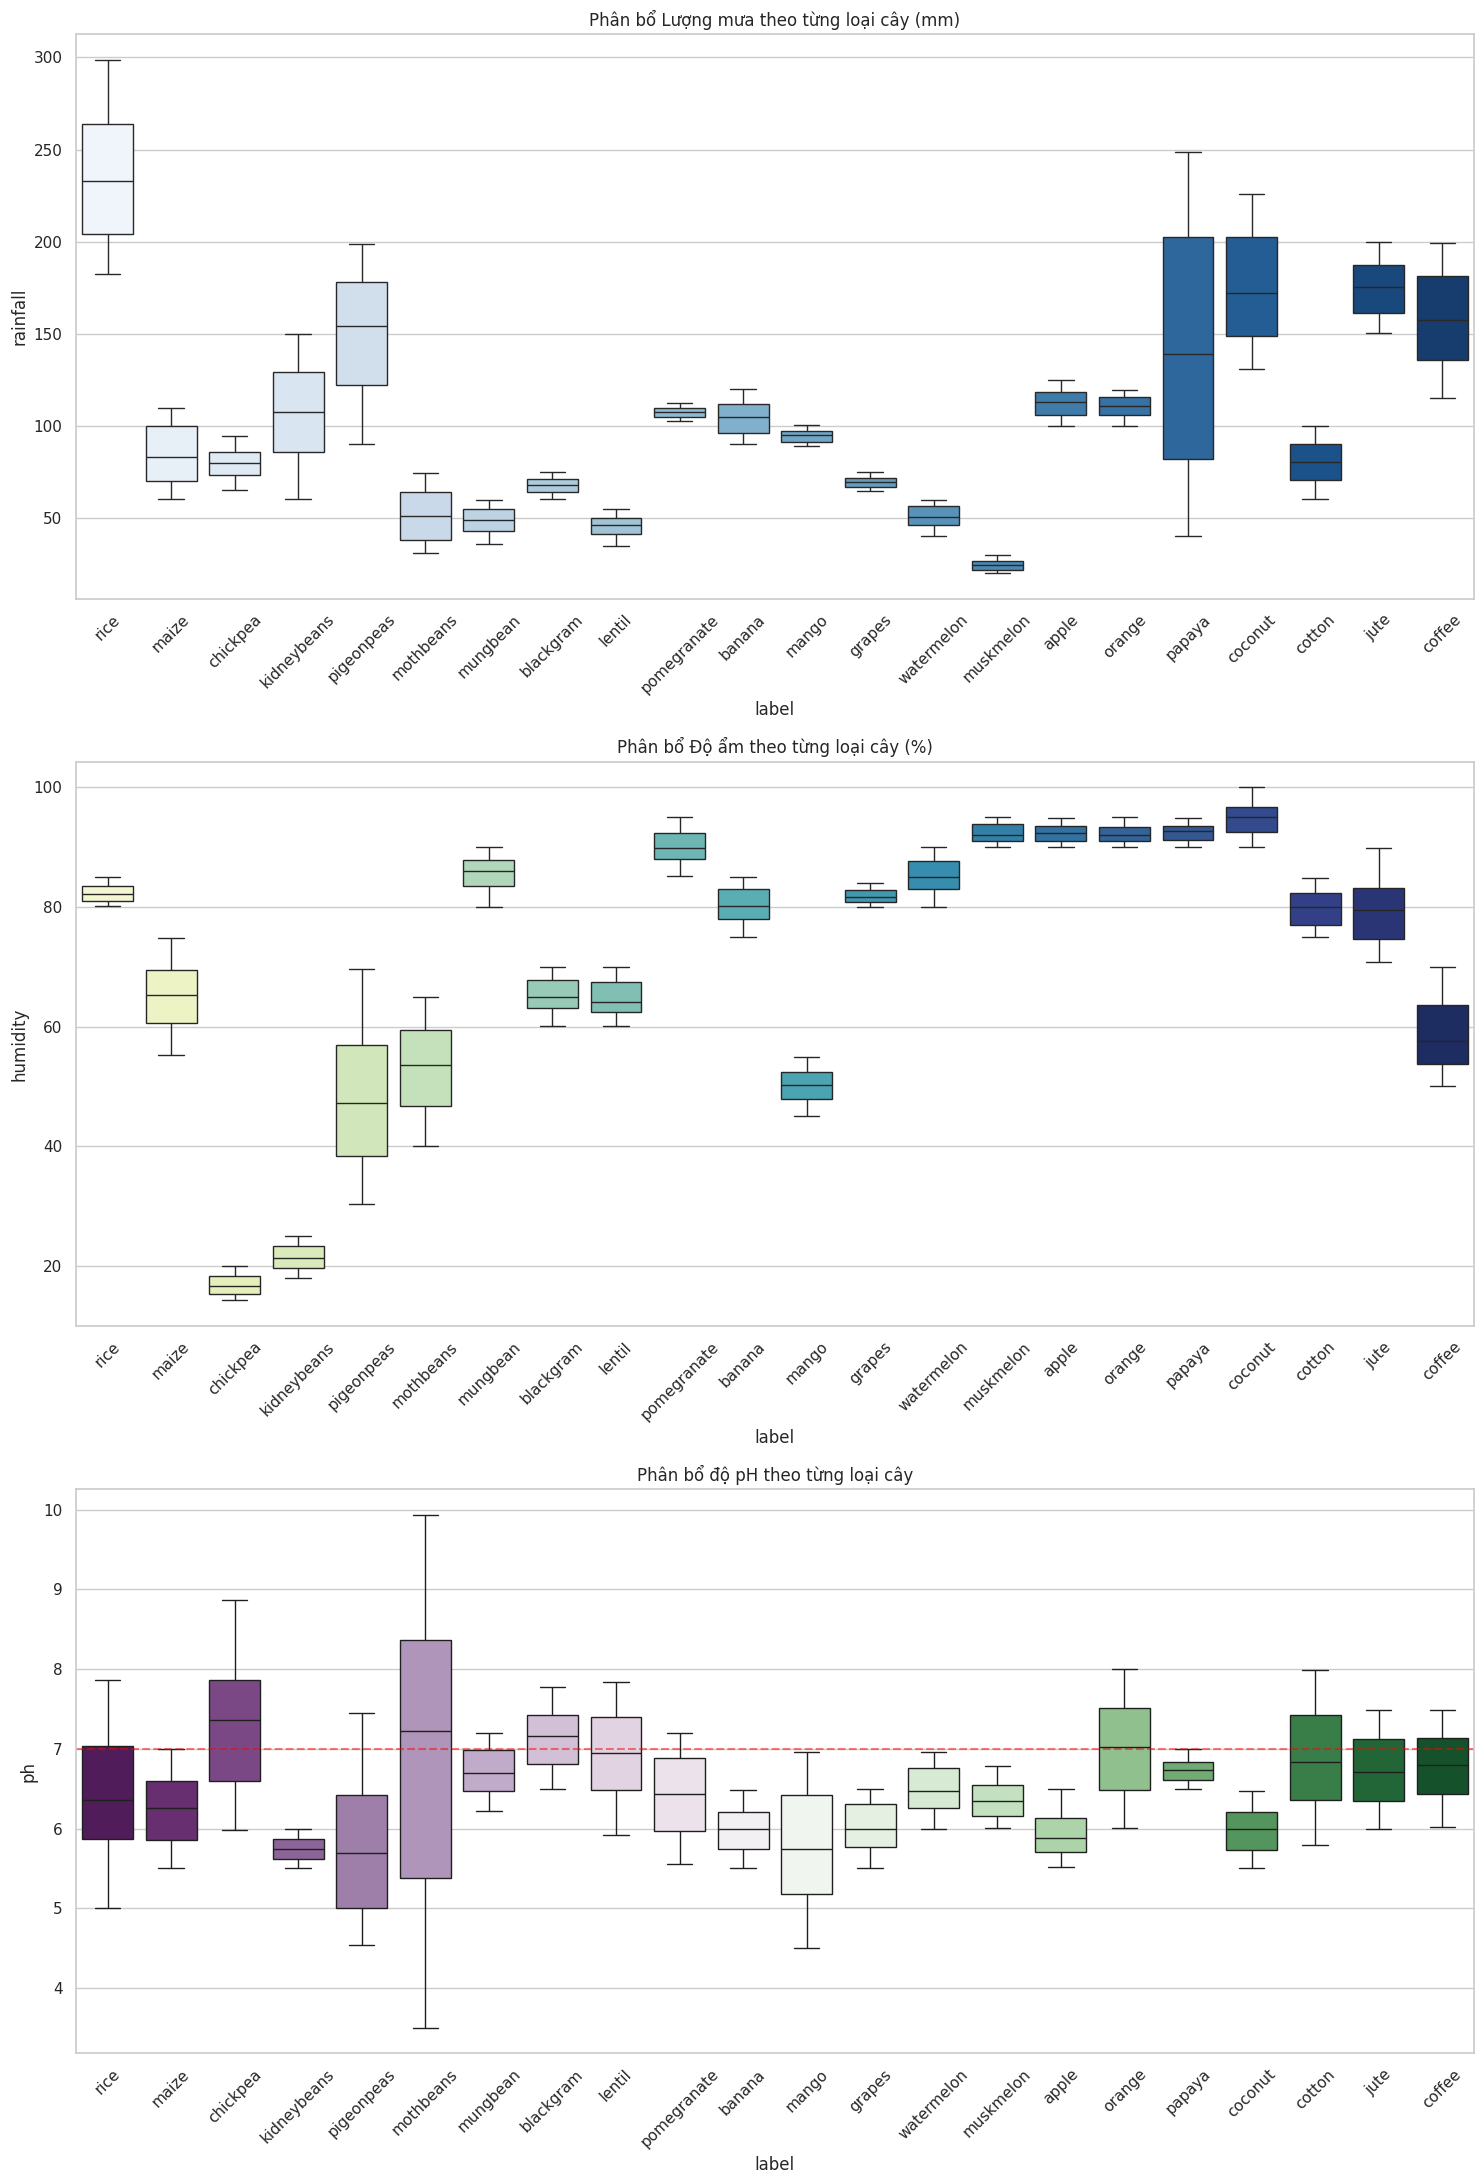

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập lưới biểu đồ (3 hàng, 1 cột)
fig, axes = plt.subplots(3, 1, figsize=(15, 22))

# 1. Boxplot cho Lượng mưa
sns.boxplot(x='label', y='rainfall', data=df, ax=axes[0], palette='Blues', hue='label', legend=False)
axes[0].set_title('Phân bổ Lượng mưa theo từng loại cây (mm)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Boxplot cho Độ ẩm
sns.boxplot(x='label', y='humidity', data=df, ax=axes[1], palette='YlGnBu', hue='label', legend=False)
axes[1].set_title('Phân bổ Độ ẩm theo từng loại cây (%)')
axes[1].tick_params(axis='x', rotation=45)

# 3. Boxplot cho pH
sns.boxplot(x='label', y='ph', data=df, ax=axes[2], palette='PRGn', hue='label', legend=False)
axes[2].set_title('Phân bổ độ pH theo từng loại cây')
axes[2].axhline(7, color='red', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Phân tích mối liên hệ giữa Môi trường và Dinh dưỡng:

1. **Nhóm Rất cao (>150mm) & Trung bình (50-80%):** Đây là nhóm có nhu cầu **Nitơ (N)** cao nhất (~90). Nhóm này bao gồm các cây như Cà phê, cho thấy môi trường mưa nhiều nhưng độ ẩm vừa phải cần cung cấp rất nhiều Đạm.
2. **Nhóm Trung bình (60-100mm) & Rất ẩm (>80%):** Nhóm này có nhu cầu **Phốt pho (P) và Kali (K)** cao đột biến (P~132, K~200). Đây chính là nơi tập trung các cây ăn quả như Nho, cần rất nhiều Lân và Kali để phát triển trái.
3. **Nhóm Thấp (<60mm) & Rất ẩm (>80%):** Nhóm chịu hạn nhưng ẩm không khí cao (như các loại Dưa) lại có nhu cầu Nitơ khá cao nhưng Phốt pho thấp, cho thấy chiến lược dinh dưỡng đặc thù.
4. **Nhóm Rất cao (>150mm) & Rất ẩm (>80%):** Nhóm của Lúa và Dừa có nhu cầu dinh dưỡng ở mức trung bình khá, cho thấy sự cân bằng trong điều kiện sinh trưởng cực đoan về nước.

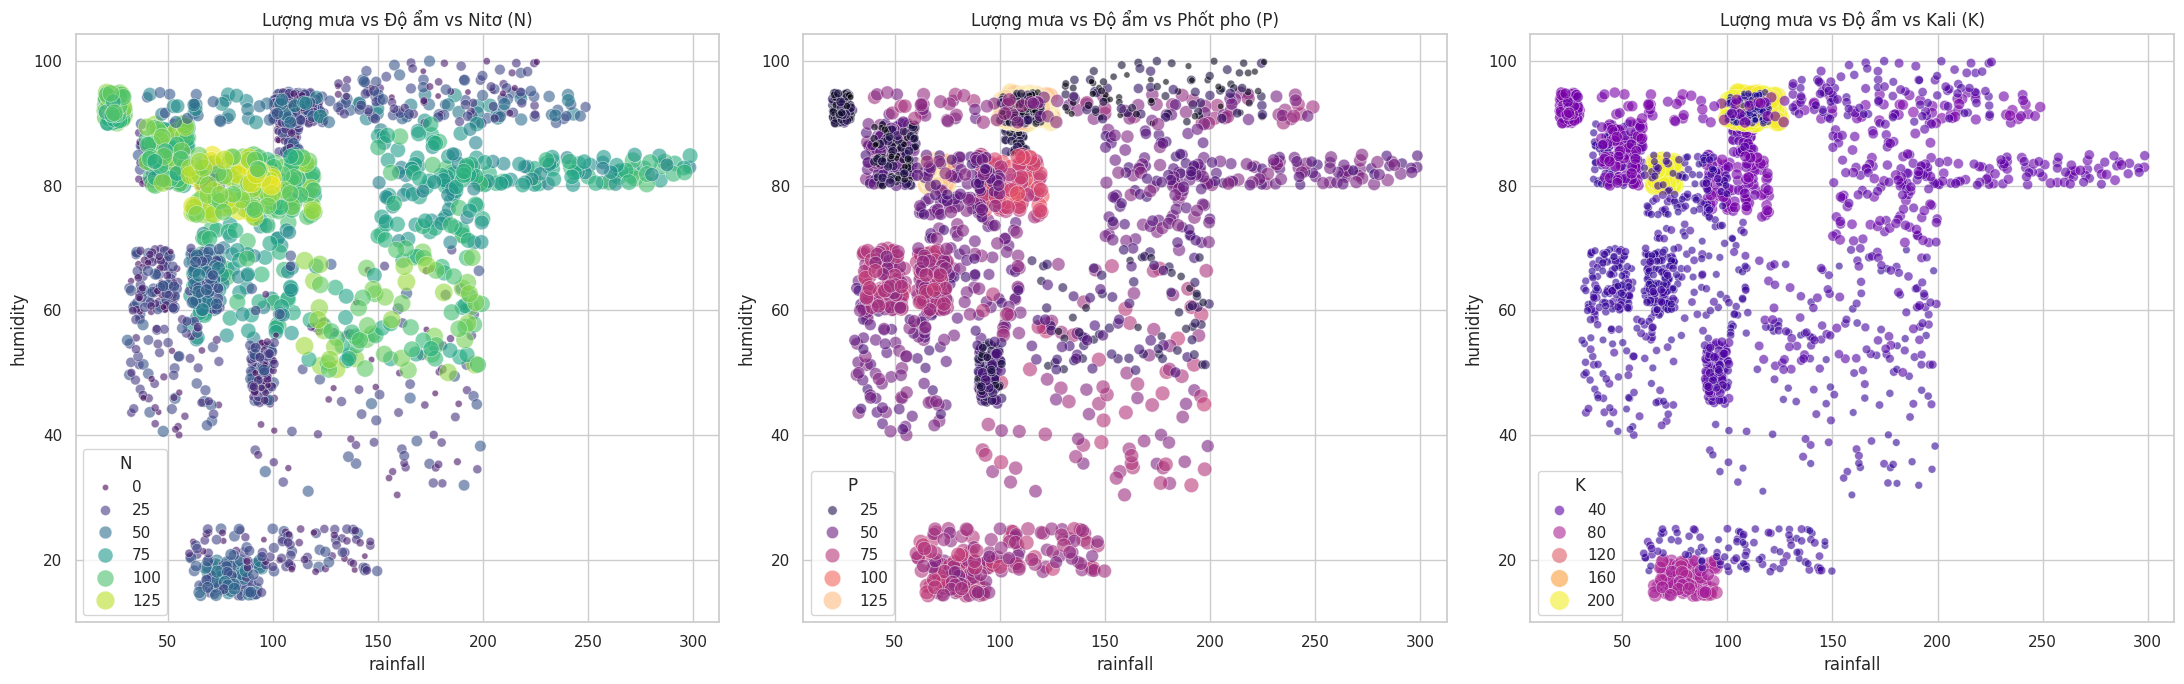

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập khung hình cho 3 biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Mối liên hệ với Nitơ (N)
sns.scatterplot(data=df, x='rainfall', y='humidity', size='N', hue='N',
                palette='viridis', sizes=(20, 200), alpha=0.6, ax=axes[0])
axes[0].set_title('Lượng mưa vs Độ ẩm vs Nitơ (N)')

# 2. Mối liên hệ với Phốt pho (P)
sns.scatterplot(data=df, x='rainfall', y='humidity', size='P', hue='P',
                palette='magma', sizes=(20, 200), alpha=0.6, ax=axes[1])
axes[1].set_title('Lượng mưa vs Độ ẩm vs Phốt pho (P)')

# 3. Mối liên hệ với Kali (K)
sns.scatterplot(data=df, x='rainfall', y='humidity', size='K', hue='K',
                palette='plasma', sizes=(20, 200), alpha=0.6, ax=axes[2])
axes[2].set_title('Lượng mưa vs Độ ẩm vs Kali (K)')

plt.tight_layout()
plt.show()

### Phân tích mối liên hệ giữa Môi trường và Dinh dưỡng thông qua biểu đồ:

1. **Nhóm Rất cao (>150mm) & Trung bình (50-80%):** Đây là nhóm có nhu cầu **Nitơ (N)** cao nhất (~90). Nhóm này bao gồm các cây như Cà phê, cho thấy môi trường mưa nhiều nhưng độ ẩm vừa phải cần cung cấp rất nhiều Đạm.
2. **Nhóm Trung bình (60-100mm) & Rất ẩm (>80%):** Nhóm này có nhu cầu **Phốt pho (P) và Kali (K)** cao đột biến (P~132, K~200). Đây chính là nơi tập trung các cây ăn quả như Nho, cần rất nhiều Lân và Kali để phát triển trái.
3. **Nhóm Thấp (<60mm) & Rất ẩm (>80%):** Nhóm chịu hạn nhưng ẩm không khí cao (như các loại Dưa) lại có nhu cầu Nitơ khá cao nhưng Phốt pho thấp, cho thấy chiến lược dinh dưỡng đặc thù.
4. **Nhóm Rất cao (>150mm) & Rất ẩm (>80%):** Nhóm của Lúa và Dừa có nhu cầu dinh dưỡng ở mức trung bình khá, cho thấy sự cân bằng trong điều kiện sinh trưởng cực đoan về nước.

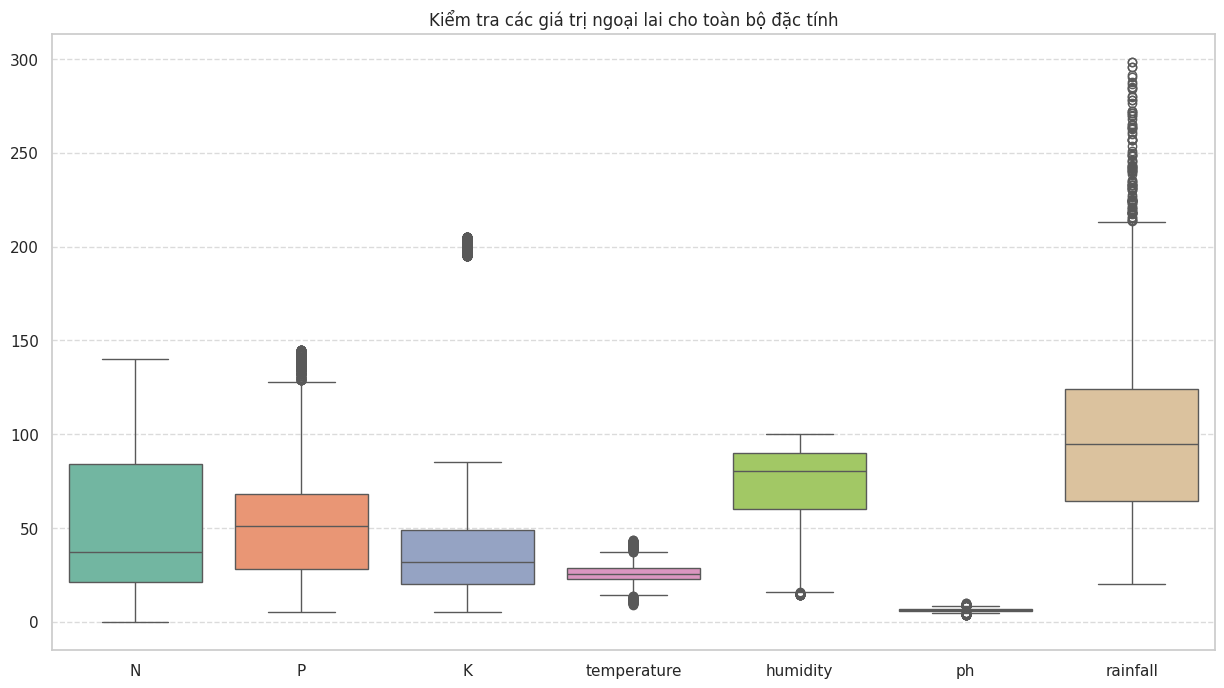

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('label', axis=1), palette='Set2')
plt.title('Kiểm tra các giá trị ngoại lai cho toàn bộ đặc tính')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()